# Workshop: Tunix-Med · Part 4: Final Evaluation & Proof of Knowledge

In this final notebook, we prove the effectiveness of our SFT training by evaluating the
**Fine-Tuned Gemma 3 270M** with its fine-tuned LoRA weights using the exact same criteria as the baseline.


## 1 · Load Fine-Tuned Model

### Tech Note: Bridging the JAX-to-PyTorch Gap
Tunix trains using JAX/Flax, which stores LoRA weights in the layout `(in_features, rank)`. However, Hugging Face's PEFT (PyTorch) expects `(rank, in_features)`. 
- **Smart Transposition**: Our `load_peft_adapter_from_tunix` function automatically detects the layout by checking the tensor shapes against the LoRA rank defined in the config. 
- **Contiguity**: When we transpose a tensor in PyTorch (`.T`), it creates a "view". We call `.contiguous()` to ensure the data is physically re-ordered in memory, which is a requirement for saving files in the `safetensors` format.

In [1]:
import os
import shutil
import tempfile
import warnings
import logging
import math
import json

import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import safetensors.torch as sft_torch

warnings.filterwarnings("ignore")
logging.getLogger("httpx").setLevel(logging.WARNING)
os.environ["TOKENIZERS_PARALLELISM"] = "false"


def info_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


device = info_device()
dtype = (
    torch.bfloat16
    if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
    else torch.float32
)
print(f"Device: {device}  |  dtype: {dtype}")

BASE_MODEL = "google/gemma-3-270m-it"
MODEL_KEY = BASE_MODEL.split("/")[1]
LOCAL_ADAPTER = "tunix-medical-model"  # output dir from notebook 03
HUB_ADAPTER = f"lmassaron/{MODEL_KEY}-medical-cardiology-lora"

# Prefer locally trained adapter; fall back to the Hub
_adapter_source = LOCAL_ADAPTER if os.path.isdir(LOCAL_ADAPTER) else HUB_ADAPTER
print(f"Adapter source : {_adapter_source}")


def load_peft_adapter_from_tunix(base_model, adapter_source):
    import huggingface_hub

    if os.path.isdir(adapter_source):
        st_file = os.path.join(adapter_source, "adapter_model.safetensors")
        cfg_file = os.path.join(adapter_source, "adapter_config.json")
    else:
        print(f"  Downloading adapter from Hub: {adapter_source}")
        st_file = huggingface_hub.hf_hub_download(
            adapter_source, "adapter_model.safetensors"
        )
        cfg_file = huggingface_hub.hf_hub_download(
            adapter_source, "adapter_config.json"
        )

    with open(cfg_file, "r") as f:
        peft_config = json.load(f)
    rank = peft_config.get("r")

    tmp_dir = tempfile.mkdtemp(prefix="peft_fixed_")
    shutil.copy(cfg_file, os.path.join(tmp_dir, "adapter_config.json"))

    raw, fixed, n_fixed = sft_torch.load_file(st_file, device="cpu"), {}, 0
    # Smart Transposition: detect JAX layout (in, rank) vs PyTorch (rank, in)
    for key, tensor in raw.items():
        if "lora_A" in key and tensor.shape[0] != rank:
            fixed[key] = tensor.T.contiguous()  # (in, rank) -> (rank, in)
            n_fixed += 1
        elif "lora_B" in key and tensor.shape[1] != rank:
            fixed[key] = tensor.T.contiguous()  # (rank, out) -> (out, rank)
            n_fixed += 1
        else:
            fixed[key] = tensor
    
    if n_fixed > 0:
        print(f"  Auto-fixed {n_fixed} LoRA tensors (JAX -> PyTorch layout)")
    
    sft_torch.save_file(fixed, os.path.join(tmp_dir, "adapter_model.safetensors"))

    peft_model = PeftModel.from_pretrained(base_model, tmp_dir)
    shutil.rmtree(tmp_dir, ignore_errors=True)
    return peft_model


print(f"Loading base model {BASE_MODEL} ...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    dtype=dtype,
    device_map="auto",
)

print("Merging LoRA adapter ...")
model = load_peft_adapter_from_tunix(base_model, _adapter_source)
model = model.merge_and_unload()
model.eval()
print("Fine-tuned model merged and ready.")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu130).
/home/lmassaron/code/gde-tpu-sprint-2026/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


Device: cuda  |  dtype: torch.bfloat16
Adapter source : tunix-medical-model
Loading base model google/gemma-3-270m-it ...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

Merging LoRA adapter ...



WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


INFO  

┌─────────────┐    ┌────────────────────────┐    ┌────────────┐    ┌─────────┐
│ GPT-QModel  │ -> │ ▓▓▓▓▓▓▓▓▓▓▓▓ 16bit     │ -> │ ▒▒▒▒ 8bit  │ -> │ ░░ 4bit │
└─────────────┘    └────────────────────────┘    └────────────┘    └─────────┘
GPT-QModel   : 6.0.3+8ace4b6
Transformers : 5.5.4
Torch        : 2.10.0+cu130
Triton       : 3.6.0


Fine-tuned model merged and ready.


## 2 · Reconstructing the Test Set (identical sampling to notebook 02)

In [2]:
DATASET_ID, EVAL_SPLIT, SEED, N_EVAL_QS = (
    "lmassaron/medical-cardiology-qa",
    0.1,
    42,
    100,
)
full_ds = load_dataset(DATASET_ID, split="train")
rng = np.random.default_rng(SEED)
all_idx = rng.permutation(len(full_ds))
eval_idx = all_idx[int(len(full_ds) * (1.0 - EVAL_SPLIT)) :]


def extract_qa(example):
    msgs = example["messages"]
    return {
        "question": next(m["content"] for m in msgs if m["role"] == "user"),
        "answer": next(m["content"] for m in msgs if m["role"] == "assistant"),
    }


rng2, seen_prefixes, qa_pairs = np.random.default_rng(SEED + 1), set(), []
for idx in rng2.permutation(eval_idx):
    if len(qa_pairs) >= N_EVAL_QS:
        break
    ex = extract_qa(full_ds[int(idx)])
    q, a = ex["question"], ex["answer"]
    if len(a) < 25:
        continue
    prefix = " ".join(q.lower().split()[:4])
    if prefix in seen_prefixes:
        continue
    seen_prefixes.add(prefix)
    qa_pairs.append({"question": q, "answer": a, "dataset_idx": int(idx)})

data = pd.DataFrame(qa_pairs)
print(f"Sampled {len(data)} questions for final testing.")

Sampled 100 questions for final testing.


## 3 · Final Inference & Fixed Perplexity

### Tech Note: Diagnosing Overfitting
By comparing the **Corpus Perplexity** of the fine-tuned model against the baseline, we can quantify the model's gain in domain knowledge. A large drop in PPL (e.g., from 17 to 8) indicates that the model has successfully internalized cardiology concepts and terminologies.

In [3]:
SYSTEM_PROMPT = (
    "You are a knowledgeable medical assistant specializing in cardiology. "
    "Answer clinical questions accurately, focusing on diagnostic criteria, "
    "treatment guidelines, and pathophysiology."
)
results_list = []

total_loss_bits = 0.0
total_tokens = 0

for _, row in tqdm(data.iterrows(), total=len(data), desc="Tuned Inference"):
    question = row["question"]
    answer = row["answer"]

    # 1. Generation
    encoded = tokenizer.apply_chat_template(
        [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question},
        ],
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(device)

    prompt_len = encoded["input_ids"].shape[-1]

    with torch.no_grad():
        out_gen = model.generate(
            **encoded,
            max_new_tokens=300,
            min_new_tokens=50,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1,
        )

    gen_text = tokenizer.decode(out_gen[0, prompt_len:], skip_special_tokens=True).strip()

    # 2. Perplexity (True Corpus PPL)
    full_ids_ppl = tokenizer.apply_chat_template(
        [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question},
            {"role": "assistant", "content": answer},
        ],
        return_tensors="pt",
        return_dict=True,
    )["input_ids"].to(device)

    labels = full_ids_ppl.clone()
    labels[:, :prompt_len] = -100

    with torch.no_grad():
        out_loss = model(full_ids_ppl, labels=labels)
        loss_i = out_loss.loss.item()

    n_answer_tokens = (labels != -100).sum().item()
    total_loss_bits += loss_i * n_answer_tokens
    total_tokens += n_answer_tokens

    # Per-example perplexity (kept for distribution charts)
    perplexity_i = math.exp(min(loss_i, 20.0))

    results_list.append(
        {
            "question": question,
            "expected_answer": answer,
            "generated_answer": gen_text,
            "perplexity": perplexity_i,
        }
    )

results_df = pd.DataFrame(results_list)
corpus_ppl = math.exp(total_loss_bits / total_tokens)
print(f"Inference complete. Corpus Perplexity: {corpus_ppl:.2f}")

Tuned Inference:   0%|          | 0/100 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Inference complete. Corpus Perplexity: 8.70


## 4 · Scoring (identical to baseline)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

_tfidf = TfidfVectorizer(
    analyzer="word", token_pattern=r"\b\w{4,}\b", sublinear_tf=True
)
_tfidf.fit(results_df["expected_answer"].tolist())
_vocab = _tfidf.vocabulary_
_idf = _tfidf.idf_


def keyword_f1_tfidf(generated: str, expected: str) -> float:
    ref_kws = set(re.findall(r"\b\w{4,}\b", expected.lower()))
    gen_kws = set(re.findall(r"\b\w{4,}\b", generated.lower()))
    if not ref_kws:
        return 1.0

    def weighted_count(kws, universe):
        return sum(
            _idf[_vocab[w]] if w in _vocab else 1.0 for w in universe if w in kws
        )

    ref_weight = sum(_idf[_vocab[w]] if w in _vocab else 1.0 for w in ref_kws)
    gen_weight = (
        sum(_idf[_vocab[w]] if w in _vocab else 1.0 for w in gen_kws)
        if gen_kws
        else 0.0
    )

    if ref_weight == 0 or gen_weight == 0:
        return 0.0
    recall = weighted_count(gen_kws, ref_kws) / ref_weight
    precision = weighted_count(ref_kws, gen_kws) / gen_weight
    return float(
        (2 * precision * recall / (precision + recall))
        if (precision + recall) > 0
        else 0.0
    )

In [5]:
from sentence_transformers import SentenceTransformer, util

sim_model = SentenceTransformer("all-MiniLM-L6-v2")


def _raw_semantic(generated: str, expected: str) -> float:
    e1 = sim_model.encode(generated, convert_to_tensor=True, show_progress_bar=False)
    e2 = sim_model.encode(expected, convert_to_tensor=True, show_progress_bar=False)
    return float(util.pytorch_cos_sim(e1, e2))

INFO:sentence_transformers.base.model:No device provided, using cuda:0
INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
from transformers import BitsAndBytesConfig

JUDGE_MODEL = "Qwen/Qwen2.5-7B-Instruct"
judge_tok = AutoTokenizer.from_pretrained(JUDGE_MODEL)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=dtype,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

judge_mdl = AutoModelForCausalLM.from_pretrained(
    JUDGE_MODEL, quantization_config=bnb_config, device_map="auto"
)


def ai_judge(question: str, generated: str, expected: str) -> float:
    prompt = (
        "You are an expert clinical cardiologist and medical education evaluator.\n"
        "Evaluate the 'Generated Answer' against the 'Reference Answer' for the given 'Question'.\n\n"
        "### SCORING RUBRIC (1-10):\n"
        "- 1: NO ANSWER (e.g., greetings, refusals, 'I am ready to help') or COMPLETELY WRONG.\n"
        "- 2-4: MAJOR ERRORS (significant inaccuracies or misses the key point).\n"
        "- 5-6: PARTIALLY CORRECT (covers some aspects but lacks depth or minor inaccuracies).\n"
        "- 7-8: MOSTLY CORRECT (aligns with the reference, but slightly incomplete or verbose).\n"
        "- 9-10: EXCELLENT (clinically precise, factual, accurate, and matches or improves on the reference).\n\n"
        "### INSTRUCTIONS:\n"
        "1. Penalize non-answers or conversational fluff with a score of 1.\n"
        "2. Score ONLY the medical accuracy and clinical relevance.\n"
        "3. Ignore chatbot niceties (e.g., 'I hope this helps').\n"
        "4. First write reasoning, then on the last line write ONLY: 'Score: [number]'\n\n"
        f"Question: {question}\n"
        f"Reference Answer: {expected}\n"
        f"Generated Answer: {generated}\n"
    )

    inp = judge_tok.apply_chat_template(
        [{"role": "user", "content": prompt}],
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(judge_mdl.device)

    with torch.no_grad():
        out = judge_mdl.generate(**inp, max_new_tokens=150, do_sample=False)

    txt = judge_tok.decode(
        out[0, inp["input_ids"].shape[-1] :], skip_special_tokens=True
    ).strip()
    
    # Improved extraction: look for "Score: X" on the last few lines
    lines = txt.splitlines()
    for line in reversed(lines):
        m = re.search(r"Score:\s*(\d+)", line)
        if m:
            return max(min(int(m.group(1)) / 10.0, 1.0), 0.1)
            
    # Fallback
    m = re.search(r"\b(\d+)\b", txt.splitlines()[-1])
    return max(min((int(m.group(1)) / 10.0) if m else 0.5, 1.0), 0.1)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [7]:
results_df["keyword_score"] = results_df.apply(
    lambda r: keyword_f1_tfidf(r["generated_answer"], r["expected_answer"]), axis=1
)
results_df["_raw_sim"] = results_df.apply(
    lambda r: _raw_semantic(r["generated_answer"], r["expected_answer"]), axis=1
)

sim_min, sim_max = results_df["_raw_sim"].min(), results_df["_raw_sim"].max()
results_df["semantic_score"] = (
    (results_df["_raw_sim"] - sim_min) / (sim_max - sim_min)
).clip(0, 1)

In [8]:
print("Running AI Judge (may take a few minutes)...")
scores = []
for _, r in tqdm(results_df.iterrows(), total=len(results_df), desc="AI Judge"):
    score = ai_judge(r["question"], r["generated_answer"], r["expected_answer"])
    scores.append(score)
results_df["ai_judge_score"] = scores

results_df["final_score"] = (
    results_df["keyword_score"] * 0.1
    + results_df["semantic_score"] * 0.3
    + results_df["ai_judge_score"] * 0.6
)

print("\n--- FINAL EVALUATION RESULTS ---")
print(f"  Mean Keyword Score  : {results_df['keyword_score'].mean():.3f}")
print(f"  Mean Semantic Score : {results_df['semantic_score'].mean():.3f}")
print(f"  Mean AI Judge Score : {results_df['ai_judge_score'].mean():.3f}")
print(f"  Mean Final Score    : {results_df['final_score'].mean():.3f}")
print(f"  Corpus Perplexity   : {corpus_ppl:.2f}")
print("---------------------------------")

results_df.to_csv("medical_final_results.csv", index=False)

Running AI Judge (may take a few minutes)...


AI Judge:   0%|          | 0/100 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



--- FINAL EVALUATION RESULTS ---
  Mean Keyword Score  : 0.242
  Mean Semantic Score : 0.756
  Mean AI Judge Score : 0.377
  Mean Final Score    : 0.477
  Corpus Perplexity   : 8.70
---------------------------------


## 5 · Workshop Results Summary

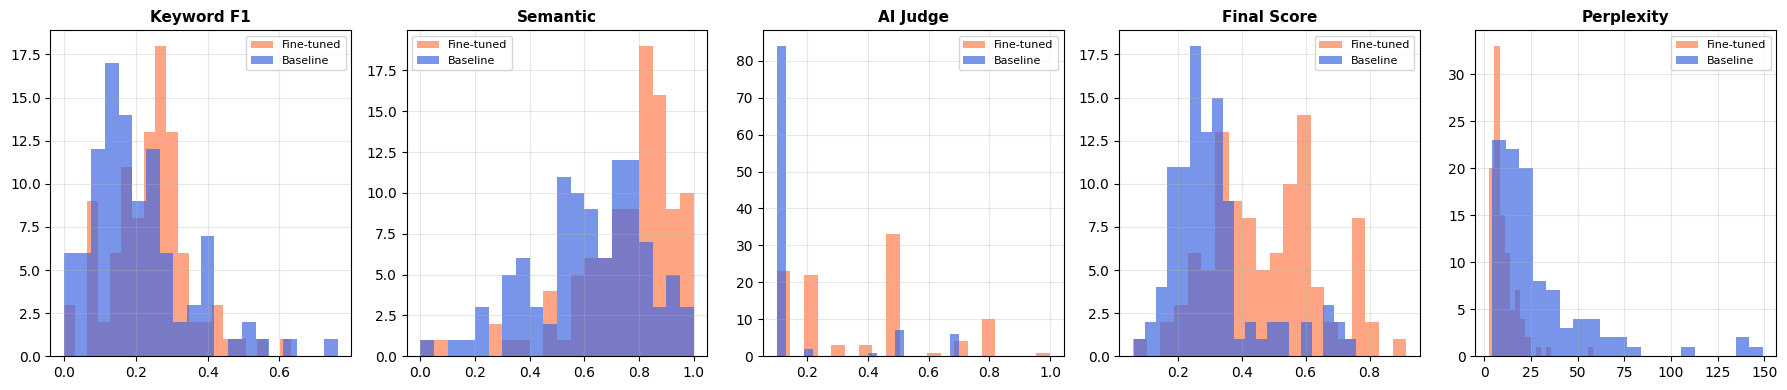

In [9]:
import matplotlib.pyplot as plt

if os.path.exists("medical_baseline_results.csv"):
    base_df = pd.read_csv("medical_baseline_results.csv")
    has_baseline = True
else:
    has_baseline = False

metrics = [
    "keyword_score",
    "semantic_score",
    "ai_judge_score",
    "final_score",
    "perplexity",
]
labels = ["Keyword F1", "Semantic", "AI Judge", "Final Score", "Perplexity"]

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))
for ax, col, label in zip(axes, metrics, labels):
    vals_ft = results_df[col]
    ax.hist(vals_ft, bins=20, alpha=0.7, color="coral", label="Fine-tuned")
    if has_baseline and col in base_df.columns:
        ax.hist(base_df[col], bins=20, alpha=0.7, color="royalblue", label="Baseline")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("final_evaluation_distributions.png", dpi=150, bbox_inches="tight")
plt.show()